# P3 — EDA Logística e Pedido

## Atraso, Frete, Tentativas e Valor do Pedido na Satisfação do Cliente

Este notebook aprofunda a análise exploratória das variáveis relacionadas à logística e ao pedido, utilizando a base processada `desafio_nps_processado_v2.csv`, versão em que os registros com `nps_score = 0` foram removidos para análise de robustez.

A versão V1 permanece como referência principal do estudo, pois mantém os clientes com NPS igual a zero, considerados Detratores genuínos. A V2 é utilizada aqui para verificar se os padrões logísticos permanecem mesmo após a remoção dos casos extremos.

O objetivo é usar estatística descritiva, visualizações e probabilidade condicional para identificar padrões que apoiem melhorias logísticas e oportunidades relacionadas ao faturamento observado.

### Foco da análise

- Atraso de entrega;
- Ponto de ruptura no atraso;
- Valor do frete;
- Peso do frete no pedido;
- Tentativas de entrega;
- Valor do pedido;
- Região;
- Faturamento observado.

## Pergunta central e hipóteses

**Pergunta central:** como atraso, frete, tentativas de entrega e valor do pedido se relacionam com a satisfação do cliente e com o faturamento observado?

### Hipóteses

- **H1:** Pedidos com atraso apresentam maior proporção de Detratores.
- **H2:** Existe um ponto de ruptura no atraso em que a proporção de Detratores aumenta de forma relevante.
- **H3:** O peso proporcional do frete no valor do pedido pode estar associado à menor satisfação.
- **H4:** Múltiplas tentativas de entrega podem estar associadas à menor satisfação.
- **H5:** Pedidos de maior valor com atraso podem estar associados a oportunidades de melhoria logística, faturamento observado e recompra.

## Como o P3 aprofunda os achados iniciais

| Dados iniciais analisados na V2 | Como o P3 aprofunda |
|---|---|
| **83,30% da base é detratora** | Verificar se Detratores se concentram em pedidos com atraso, frete alto ou múltiplas tentativas |
| **NPS oficial ≈ -78,61** | Investigar quais variáveis logísticas estão associadas à baixa satisfação |
| **Atraso permanece como principal variável negativa** | Analisar atraso por faixa, média, mediana, correlação e probabilidade condicional |
| **Recompra permanece como principal sinal positivo** | Usar recompra como visão de faturamento e retenção, sem aprofundar atendimento |
| **A remoção dos NPS=0 não altera a estrutura do problema** | Validar se os padrões de logística e pedido continuam presentes mesmo sem os extremos |
| **Regiões serão avaliadas como recorte operacional** | Verificar se o comportamento logístico é sistêmico ou se existem diferenças relevantes por região |

## 0. Preparação do ambiente

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from scipy.stats import chi2_contingency, kruskal

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Carregamento da base e validação inicial

A base utilizada neste notebook corresponde à versão V2 do tratamento, na qual registros com `nps_score = 0` foram removidos como outliers para análise de robustez.

A validação inicial verifica estrutura, tipos de dados, nulos, duplicidades e estatísticas gerais antes do aprofundamento do EDA de logística e pedido.

In [2]:
from pathlib import Path

path_v2 = Path("desafio_nps_processado_v2.csv")

if path_v2.exists():
    df = pd.read_csv(path_v2)
elif path_v1.exists():
    df = pd.read_csv(path_v1)
    df = df[df["nps_score"] > 0].copy().reset_index(drop=True)
else:
    raise FileNotFoundError("Arquivo desafio_nps_processado_v2.csv não encontrado.")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,classificacao_nps,eh_detrator,teve_atraso,teve_reclamacao,contatou_sac,severidade_problemas,desconto_pct
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50,Detrator,1,1,1,0,2,0.28
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00,Detrator,1,1,1,0,2,0.02
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50,Detrator,1,1,1,1,3,0.08
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30,Detrator,1,1,1,1,3,0.06
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90,Detrator,1,1,1,1,3,0.12


In [3]:
df.shape

(2342, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2342 entries, 0 to 2341
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2342 non-null   int64  
 1   customer_age               2342 non-null   int64  
 2   customer_region            2342 non-null   object 
 3   customer_tenure_months     2342 non-null   int64  
 4   order_id                   2342 non-null   int64  
 5   order_value                2342 non-null   float64
 6   items_quantity             2342 non-null   int64  
 7   discount_value             2342 non-null   float64
 8   payment_installments       2342 non-null   int64  
 9   delivery_time_days         2342 non-null   int64  
 10  delivery_delay_days        2342 non-null   int64  
 11  freight_value              2342 non-null   float64
 12  delivery_attempts          2342 non-null   int64  
 13  customer_service_contacts  2342 non-null   int64

In [5]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,eh_detrator,teve_atraso,teve_reclamacao,contatou_sac,severidade_problemas,desconto_pct
count,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00
mean,1256.07,43.31,61.30,51256.07,435.41,3.48,29.84,6.00,8.01,2.06,38.16,2.01,1.44,5.43,4.67,0.09,4.04,3.09,0.83,0.88,0.99,0.77,2.64,0.13
std,726.45,14.96,34.53,726.45,290.37,1.69,29.44,3.16,3.77,1.36,12.08,0.81,1.18,3.46,2.31,0.29,1.73,2.36,0.37,0.32,0.10,0.42,0.57,0.26
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,626.25,31.00,31.00,50626.25,220.31,2.00,8.90,3.00,5.00,1.00,29.92,1.00,1.00,2.00,2.90,0.00,3.00,1.00,1.00,1.00,1.00,1.00,2.00,0.02
50%,1257.50,43.00,62.00,51257.50,376.43,3.00,20.94,6.00,8.00,2.00,38.38,2.00,1.00,5.00,4.60,0.00,4.00,2.90,1.00,1.00,1.00,1.00,3.00,0.06
75%,1891.50,56.00,91.00,51891.50,583.58,5.00,40.77,9.00,11.00,3.00,46.23,3.00,2.00,8.00,6.20,0.00,5.00,4.90,1.00,1.00,1.00,1.00,3.00,0.13
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,7.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00,1.00,1.00,1.00,1.00,3.00,3.76


## 2. Distribuição da classificação NPS

Esta etapa confirma a composição da base V2 entre Detratores, Neutros e Promotores e calcula o NPS oficial pela regra:

**NPS oficial = % Promotores − % Detratores**

In [8]:
dist_nps = df["classificacao_nps"].value_counts(normalize=True) * 100
dist_nps = dist_nps.reindex(["Detrator", "Neutro", "Promotor"])

nps_oficial = dist_nps["Promotor"] - dist_nps["Detrator"]

print("Distribuição das categorias de NPS:")
print(dist_nps.round(2))
print(f"NPS oficial: {nps_oficial:.2f}")

Distribuição das categorias de NPS:
classificacao_nps
Detrator   83.30
Neutro     12.00
Promotor    4.70
Name: proportion, dtype: float64
NPS oficial: -78.61


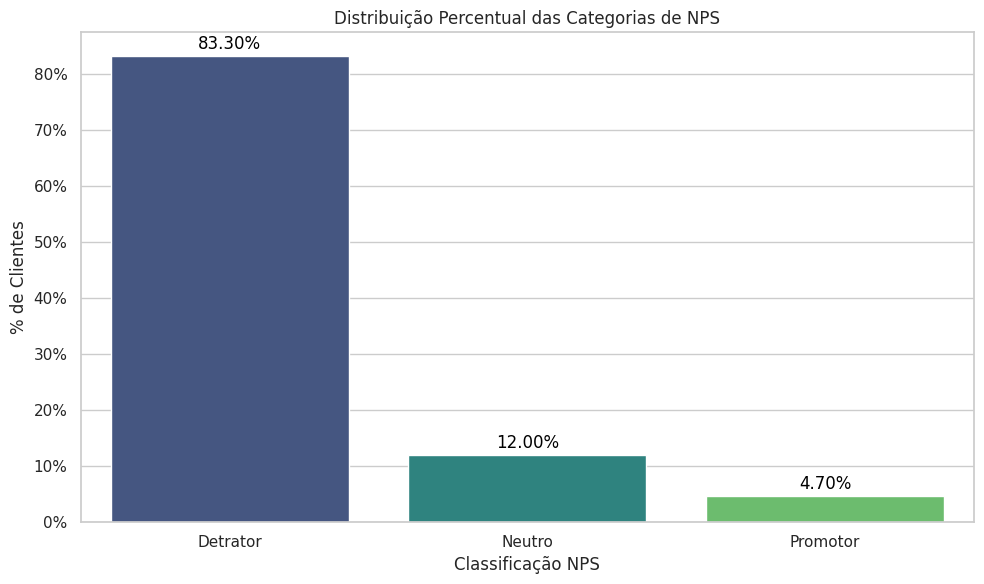

In [64]:
dist_nps_df = dist_nps.reset_index()
dist_nps_df.columns = ["Classificação NPS", "% de Clientes"]

plt.figure(figsize=(10, 6))
sns.barplot(data=dist_nps_df, x="Classificação NPS", y="% de Clientes", order=["Detrator", "Neutro", "Promotor"], hue="Classificação NPS", palette="viridis", legend=False)
plt.title("Distribuição Percentual das Categorias de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("% de Clientes")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

for index, row in dist_nps_df.iterrows():
    plt.text(row.name, row["% de Clientes"] + 0.5, f'{row["% de Clientes"]:.2f}%', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

A distribuição da variável `classificacao_nps` permite observar a composição da base entre Detratores, Neutros e Promotores. Como esta versão da base remove os registros com `nps_score = 0`, a leitura dos percentuais deve considerar que a análise está sendo feita sobre a base V2.

A base V2 ainda apresenta forte concentração de Detratores e NPS oficial negativo, mantendo um cenário crítico de satisfação mesmo após a remoção dos casos extremos.

## 3. Criação e validação das variáveis derivadas

Nesta etapa são criadas variáveis derivadas para aprofundar a análise de logística e pedido:

- `freight_ratio`: peso proporcional do frete no valor do pedido;
- `has_multiple_attempts`: indica se houve mais de uma tentativa de entrega;
- `delay_range`: classifica os pedidos por faixas de atraso.

In [61]:
df["freight_ratio"] = np.where(df["order_value"] > 0, df["freight_value"] / df["order_value"], np.nan)
df["has_multiple_attempts"] = df["delivery_attempts"] > 1
df["teve_atraso"] = (df["delivery_delay_days"] > 0).astype(int)

max_delay_value = df["delivery_delay_days"].max()
bins = [-1, 0, 1, 3, 5, 10]
labels = ["Sem atraso", "Até 1 dia", "2 a 3 dias", "4 a 5 dias", "6 a 10 dias"]

if max_delay_value > 10:
    bins.append(max_delay_value)
    labels.append("Acima de 10 dias")

df["delay_range"] = pd.cut(df["delivery_delay_days"], bins=bins, labels=labels, include_lowest=True)


In [11]:
df[["delivery_delay_days", "delay_range", "freight_value", "order_value", "freight_ratio", "delivery_attempts", "has_multiple_attempts"]].head()

,delivery_delay_days,delay_range,freight_value,order_value,freight_ratio,delivery_attempts,has_multiple_attempts
0,2,2 a 3 dias,55.53,139.73,0.40,3,True
1,4,4 a 5 dias,28.23,458.95,0.06,3,True
2,1,Até 1 dia,40.99,507.06,0.08,1,False
3,2,2 a 3 dias,35.24,302.19,0.12,3,True
4,1,Até 1 dia,39.32,253.06,0.16,1,False


In [12]:
df["delay_range"].value_counts(dropna=False).sort_index()

,count
delay_range,
Sem atraso,277
Até 1 dia,610
2 a 3 dias,1118
4 a 5 dias,309
6 a 10 dias,28


In [13]:
df["has_multiple_attempts"].value_counts(normalize=True) * 100

,proportion
has_multiple_attempts,
True,67.29
False,32.71


Após a criação das variáveis derivadas, foi realizada uma validação para verificar se as faixas de atraso, o peso proporcional do frete e a marcação de múltiplas tentativas foram gerados corretamente.

## 4. Estatística descritiva de logística e pedido

Nesta etapa, comparamos as principais variáveis de logística e pedido entre Detratores, Neutros e Promotores.

O objetivo é observar diferenças de média, mediana, dispersão e valores extremos em atraso de entrega, tempo de entrega, frete, peso proporcional do frete, valor do pedido, quantidade de itens e tentativas de entrega.

In [14]:
logistics_cols = ["delivery_delay_days", "delivery_time_days", "freight_value", "freight_ratio", "order_value", "items_quantity", "delivery_attempts"]
estatistica_logistica = df.groupby("classificacao_nps")[logistics_cols].agg(["count", "mean", "median", "std", "min", "max"])
estatistica_logistica

delivery_delay_days                           \
                                count mean median  std min max   
classificacao_nps                                                
Detrator                         1951 2.28   2.00 1.33   0   7   
Neutro                            281 1.05   1.00 0.89   0   4   
Promotor                          110 0.72   1.00 0.78   0   3   

                  delivery_time_days                          freight_value  \
                               count mean median  std min max         count   
classificacao_nps                                                             
Detrator                        1951 7.98   8.00 3.76   2  14          1951   
Neutro                           281 8.26   8.00 3.76   2  14           281   
Promotor                         110 7.94   8.00 3.82   2  14           110   

                                                freight_ratio              \
                   mean median   std  min   max         count mean median   
classificacao_nps                                                           
Detrator          38.23  38.67 12.04 2.62 76.13          1951 0.16   0.10   
Neutro            38.06  37.35 12.17 5.51 72.45           281 0.14   0.09   
Promotor          37.05  36.25 12.61 4.08 69.43           110 0.13   0.08   

                                 order_value                             \
                   std  min  max       count   mean median    std   min   
classificacao_nps                                                         
Detrator          0.20 0.00 3.27        1951 430.29 374.67 287.62  7.76   
Neutro            0.13 0.01 0.90         281 458.17 382.78 311.36 33.29   
Promotor          0.12 0.01 0.70         110 468.08 402.68 281.02 64.87   

                          items_quantity                           \
                      max          count mean median  std min max   
classificacao_nps                                                   
Detrator          1983.81           1951 3.50   3.00 1.69   1   6   
Neutro            1826.22            281 3.31   3.00 1.74   1   6   
Promotor          1372.62            110 3.64   4.00 1.62   1   6   

                  delivery_attempts                           
                              count mean median  std min max  
classificacao_nps                                             
Detrator                       1951 2.00   2.00 0.81   1   3  
Neutro                          281 2.01   2.00 0.84   1   3  
Promotor                        110 2.15   2.00 0.86   1   3

A estatística descritiva por categoria de NPS permite comparar o comportamento das variáveis logísticas e de pedido entre Detratores, Neutros e Promotores.

A média mostra o comportamento geral de cada grupo, a mediana reduz o impacto de valores extremos, o desvio padrão indica a dispersão dos dados e os valores mínimo e máximo ajudam a observar possíveis outliers.

## 5. Atraso de entrega por categoria de NPS

Como o EDA geral indicou forte associação negativa entre atraso e NPS, esta etapa aprofunda a análise do atraso de entrega entre Detratores, Neutros e Promotores.

In [15]:
atraso_por_nps = df.groupby("classificacao_nps")["delivery_delay_days"].agg(["count", "mean", "median", "std", "min", "max"])
atraso_por_nps

,count,mean,median,std,min,max
classificacao_nps,,,,,,
Detrator,1951,2.28,2.00,1.33,0,7
Neutro,281,1.05,1.00,0.89,0,4
Promotor,110,0.72,1.00,0.78,0,3


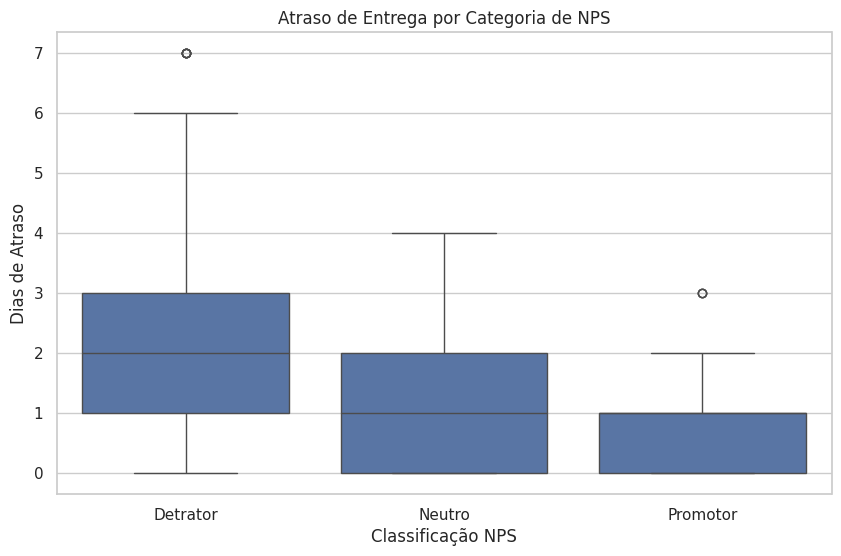

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="classificacao_nps", y="delivery_delay_days", order=["Detrator", "Neutro", "Promotor"])
plt.title("Atraso de Entrega por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Dias de Atraso")
plt.show()

A comparação do atraso de entrega por categoria de NPS permite observar se os clientes Detratores apresentam maior atraso em relação aos Neutros e Promotores.

Se Detratores apresentarem média, mediana ou dispersão superior, isso reforça a hipótese de que a experiência logística está associada à concentração de insatisfação.

## 6. Probabilidade condicional: classificação NPS dado atraso

Nesta etapa, comparamos a distribuição percentual de Detratores, Neutros e Promotores entre pedidos com e sem atraso.

O objetivo é observar se a proporção de Detratores aumenta quando há atraso na entrega.

In [17]:
delay_nps = pd.crosstab(df["teve_atraso"], df["classificacao_nps"], normalize="index") * 100
delay_nps = delay_nps.reindex(columns=["Detrator", "Neutro", "Promotor"])
delay_nps

classificacao_nps,Detrator,Neutro,Promotor
teve_atraso,,,
0,51.62,30.32,18.05
1,87.55,9.54,2.91


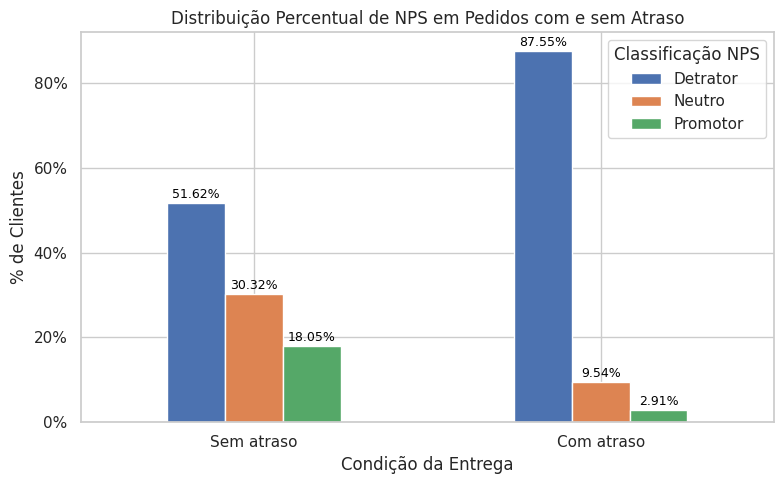

In [65]:
delay_nps_plot = delay_nps.copy()
delay_nps_plot.index = delay_nps_plot.index.map({0: "Sem atraso", 1: "Com atraso"})
ax = delay_nps_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Distribuição Percentual de NPS em Pedidos com e sem Atraso")
plt.xlabel("Condição da Entrega")
plt.ylabel("% de Clientes")
plt.xticks(rotation=0)
plt.legend(title="Classificação NPS")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter()) # Add percent formatter to y-axis

for container in ax.containers:
    for i, bar in enumerate(container):
        value = bar.get_height()
        if value > 0: # Only label bars with a value greater than 0
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{value:.2f}%',
                    ha='center', va='bottom', color='black', fontsize=9) # Add percentage labels

plt.tight_layout()
plt.show()

A tabela apresenta a distribuição percentual das categorias de NPS dentro dos grupos com e sem atraso. Essa é uma análise de probabilidade condicional, pois observa a probabilidade de cada classificação de NPS dado que o pedido teve ou não atraso.

O resultado não indica causalidade, mas mostra um padrão relevante para decisões de melhoria logística.

## 7. Ponto de ruptura no atraso

Nesta etapa, analisamos as faixas de atraso para identificar se existe um intervalo em que a proporção de Detratores aumenta de forma mais relevante.

Essa análise ajuda a transformar o atraso em uma informação operacional útil para logística, pois permite observar em qual faixa a experiência do cliente começa a se deteriorar com maior intensidade.

In [19]:
delay_range_nps = pd.crosstab(df["delay_range"], df["classificacao_nps"], normalize="index") * 100
delay_range_nps = delay_range_nps.reindex(columns=["Detrator", "Neutro", "Promotor"])
delay_range_nps

classificacao_nps,Detrator,Neutro,Promotor
delay_range,,,
Sem atraso,51.62,30.32,18.05
Até 1 dia,73.77,19.02,7.21
2 a 3 dias,91.50,7.07,1.43
4 a 5 dias,99.35,0.65,0.00
6 a 10 dias,100.00,0.00,0.00


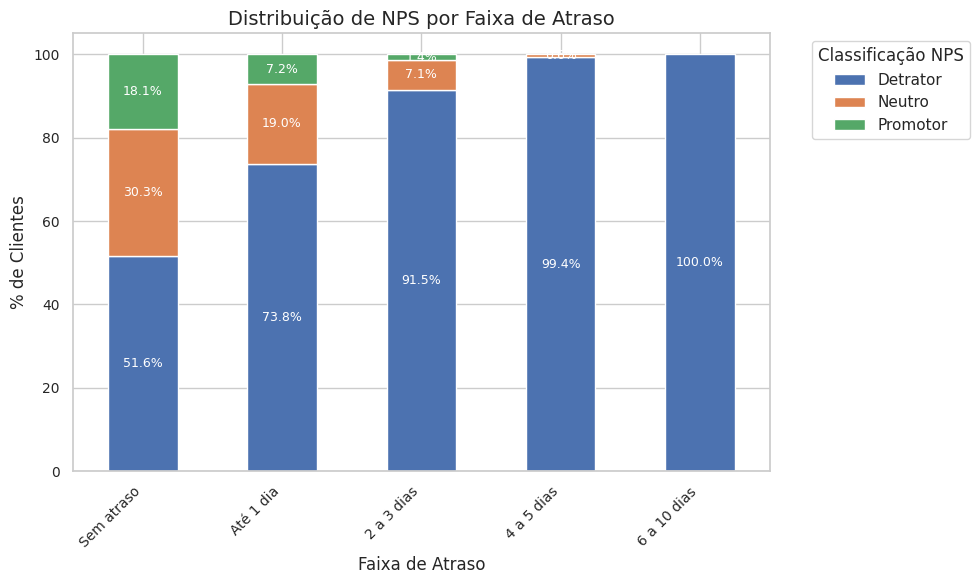

In [66]:
ax = delay_range_nps.plot(kind="bar", figsize=(10, 6), stacked=True) # Use stacked for clarity
plt.title("Distribuição de NPS por Faixa de Atraso", fontsize=14) # Increase title font size
plt.xlabel("Faixa de Atraso", fontsize=12) # Increase x-label font size
plt.ylabel("% de Clientes", fontsize=12) # Increase y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate and align x-axis labels
plt.yticks(fontsize=10)

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white') # Center labels, white color for contrast

plt.legend(title="Classificação NPS", bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [21]:
detratores_por_faixa = delay_range_nps["Detrator"].sort_index()
detratores_por_faixa

,Detrator
delay_range,
Sem atraso,51.62
Até 1 dia,73.77
2 a 3 dias,91.50
4 a 5 dias,99.35
6 a 10 dias,100.00


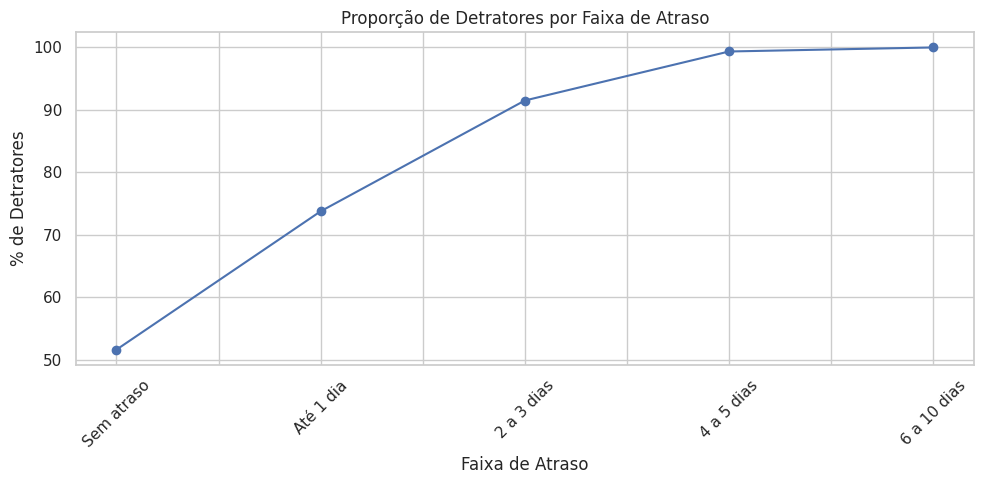

In [22]:
detratores_por_faixa.plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Proporção de Detratores por Faixa de Atraso")
plt.xlabel("Faixa de Atraso")
plt.ylabel("% de Detratores")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A análise por faixa de atraso permite observar se existe um ponto de ruptura na experiência logística. Esse ponto representa o intervalo em que a proporção de Detratores começa a aumentar de forma mais evidente.

Essa leitura é importante porque transforma o atraso em um limite operacional observável.

## 8. Frete e peso proporcional do frete no pedido

Depois de analisar o atraso e o ponto de ruptura, esta etapa investiga o comportamento do frete entre Detratores, Neutros e Promotores.

O objetivo é observar tanto o valor absoluto do frete quanto o peso proporcional do frete no pedido. Para isso, usamos a variável `freight_ratio`, que representa a relação entre `freight_value` e `order_value`.

In [23]:
frete_por_nps = df.groupby("classificacao_nps")["freight_value"].agg(["count", "mean", "median", "std", "min", "max"])
frete_por_nps

,count,mean,median,std,min,max
classificacao_nps,,,,,,
Detrator,1951,38.23,38.67,12.04,2.62,76.13
Neutro,281,38.06,37.35,12.17,5.51,72.45
Promotor,110,37.05,36.25,12.61,4.08,69.43


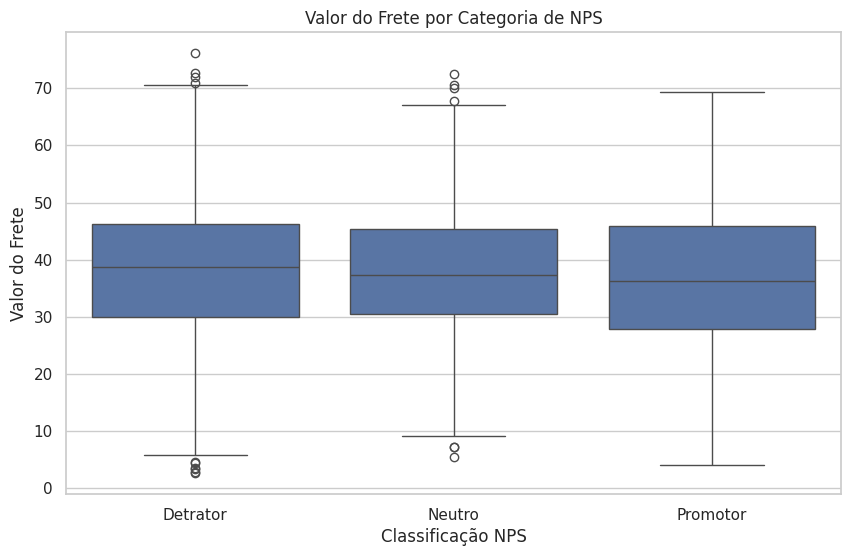

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="classificacao_nps", y="freight_value", order=["Detrator", "Neutro", "Promotor"])
plt.title("Valor do Frete por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Valor do Frete")
plt.show()

In [25]:
freight_ratio_por_nps = df.groupby("classificacao_nps")["freight_ratio"].agg(["count", "mean", "median", "std", "min", "max"])
freight_ratio_por_nps

,count,mean,median,std,min,max
classificacao_nps,,,,,,
Detrator,1951,0.16,0.10,0.20,0.00,3.27
Neutro,281,0.14,0.09,0.13,0.01,0.90
Promotor,110,0.13,0.08,0.12,0.01,0.70


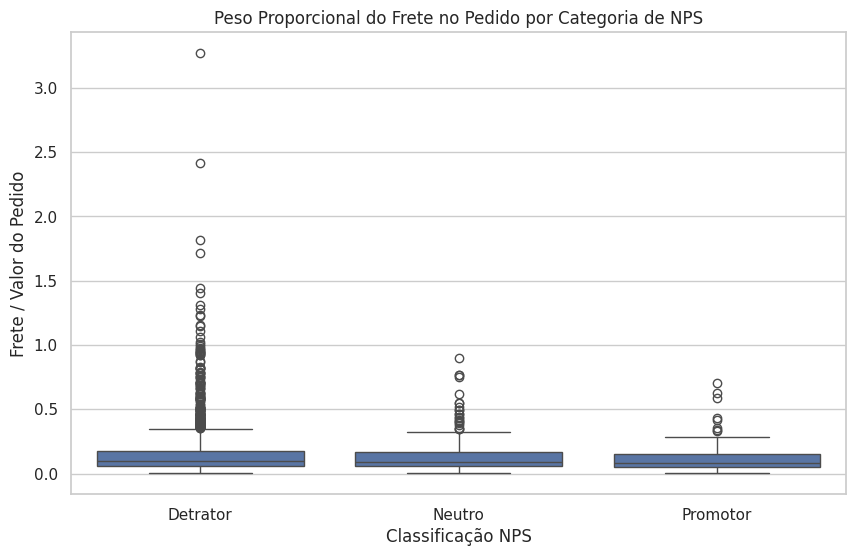

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="classificacao_nps", y="freight_ratio", order=["Detrator", "Neutro", "Promotor"])
plt.title("Peso Proporcional do Frete no Pedido por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Frete / Valor do Pedido")
plt.show()

A análise do frete absoluto permite observar se o custo médio de entrega apresenta diferenças entre Detratores, Neutros e Promotores.

Já o `freight_ratio` complementa essa leitura ao mostrar quanto o frete representa proporcionalmente no valor total do pedido.

## 9. Tentativas de entrega

Depois da análise de atraso e frete, esta etapa avalia se múltiplas tentativas de entrega estão associadas a diferenças na classificação de NPS.

A variável `delivery_attempts` representa a quantidade de tentativas realizadas para concluir a entrega. A partir dela, usamos a variável derivada `has_multiple_attempts`, que indica se o pedido teve mais de uma tentativa de entrega.

In [27]:
tentativas_por_nps = df.groupby("classificacao_nps")["delivery_attempts"].agg(["count", "mean", "median", "std", "min", "max"])
tentativas_por_nps

,count,mean,median,std,min,max
classificacao_nps,,,,,,
Detrator,1951,2.00,2.00,0.81,1,3
Neutro,281,2.01,2.00,0.84,1,3
Promotor,110,2.15,2.00,0.86,1,3


In [28]:
df["delivery_attempts"].value_counts().sort_index()

,count
delivery_attempts,
1,766
2,787
3,789


In [29]:
df["has_multiple_attempts"].value_counts(normalize=True) * 100

,proportion
has_multiple_attempts,
True,67.29
False,32.71


In [30]:
attempts_nps = pd.crosstab(df["has_multiple_attempts"], df["classificacao_nps"], normalize="index") * 100
attempts_nps = attempts_nps.reindex(columns=["Detrator", "Neutro", "Promotor"])
attempts_nps

classificacao_nps,Detrator,Neutro,Promotor
has_multiple_attempts,,,
False,83.03,12.66,4.31
True,83.44,11.68,4.89


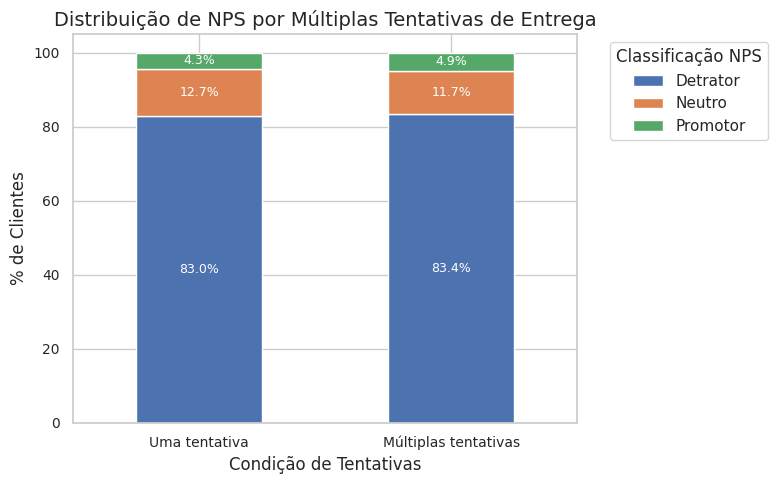

In [68]:
attempts_nps_plot = attempts_nps.copy()
attempts_nps_plot.index = attempts_nps_plot.index.map({False: "Uma tentativa", True: "Múltiplas tentativas"})
ax = attempts_nps_plot.plot(kind="bar", figsize=(8, 5), stacked=True) # Use stacked for clarity
plt.title("Distribuição de NPS por Múltiplas Tentativas de Entrega", fontsize=14)
plt.xlabel("Condição de Tentativas", fontsize=12)
plt.ylabel("% de Clientes", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white')

plt.legend(title="Classificação NPS", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

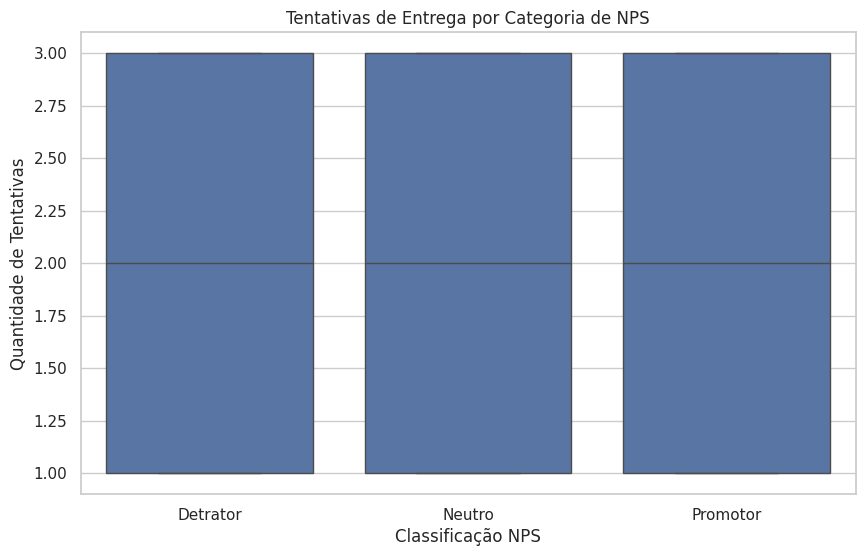

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="classificacao_nps", y="delivery_attempts", order=["Detrator", "Neutro", "Promotor"])
plt.title("Tentativas de Entrega por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Quantidade de Tentativas")
plt.show()

A análise de tentativas de entrega permite observar se pedidos com mais de uma tentativa apresentam maior concentração de Detratores.

Quando uma entrega exige múltiplas tentativas, isso pode indicar fricção logística, falha de comunicação, ausência do cliente, dificuldade de roteirização ou necessidade de reprocessamento operacional.

## 10. Faturamento por categoria de NPS

Depois de analisar atraso, frete e tentativas de entrega, esta etapa avalia o faturamento observado por categoria de NPS.

O objetivo é verificar se Detratores, Neutros e Promotores apresentam diferenças em volume de pedidos, faturamento total, ticket médio e mediana do valor do pedido.

In [33]:
faturamento_nps = df.groupby("classificacao_nps").agg(
    total_pedidos=("order_value", "count"),
    faturamento_total=("order_value", "sum"),
    ticket_medio=("order_value", "mean"),
    mediana_pedido=("order_value", "median"),
    atraso_medio=("delivery_delay_days", "mean"),
    tentativas_medias=("delivery_attempts", "mean"),
    recompra_media_30d=("repeat_purchase_30d", "mean")
).reindex(["Detrator", "Neutro", "Promotor"])

faturamento_nps["participacao_faturamento_%"] = (faturamento_nps["faturamento_total"] / faturamento_nps["faturamento_total"].sum()) * 100

# Aplicar formatação de moeda para as colunas relevantes
formatted_faturamento_nps = faturamento_nps.copy()
for col in ["faturamento_total", "ticket_medio", "mediana_pedido"]:
    formatted_faturamento_nps[col] = formatted_faturamento_nps[col].apply(lambda x: f"R$ {x:,.2f}")

display(formatted_faturamento_nps)

,total_pedidos,faturamento_total,ticket_medio,mediana_pedido,atraso_medio,tentativas_medias,recompra_media_30d,participacao_faturamento_%
classificacao_nps,,,,,,,,
Detrator,1951,"R$ 839,494.45",R$ 430.29,R$ 374.67,2.28,2.00,0.00,82.33
Neutro,281,"R$ 128,746.27",R$ 458.17,R$ 382.78,1.05,2.01,0.38,12.63
Promotor,110,"R$ 51,489.26",R$ 468.08,R$ 402.68,0.72,2.15,1.00,5.05


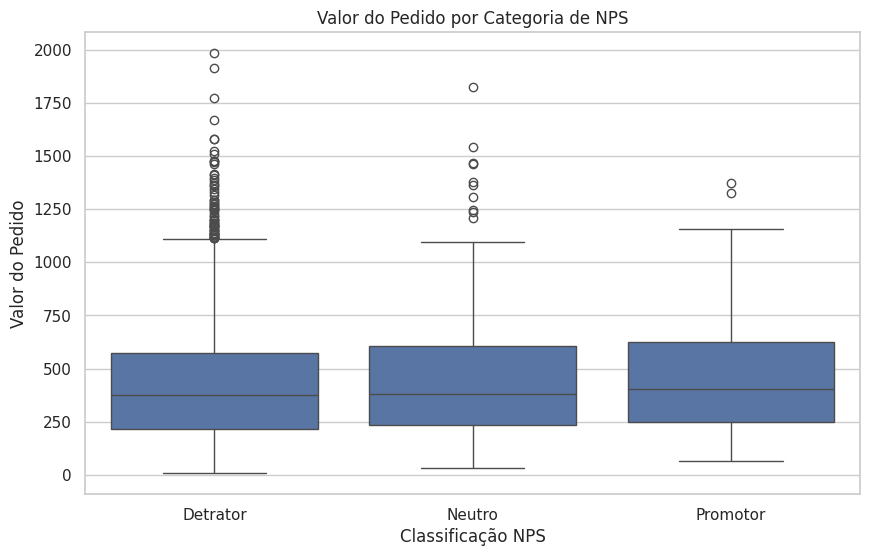

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="classificacao_nps", y="order_value", order=["Detrator", "Neutro", "Promotor"])
plt.title("Valor do Pedido por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Valor do Pedido")
plt.show()

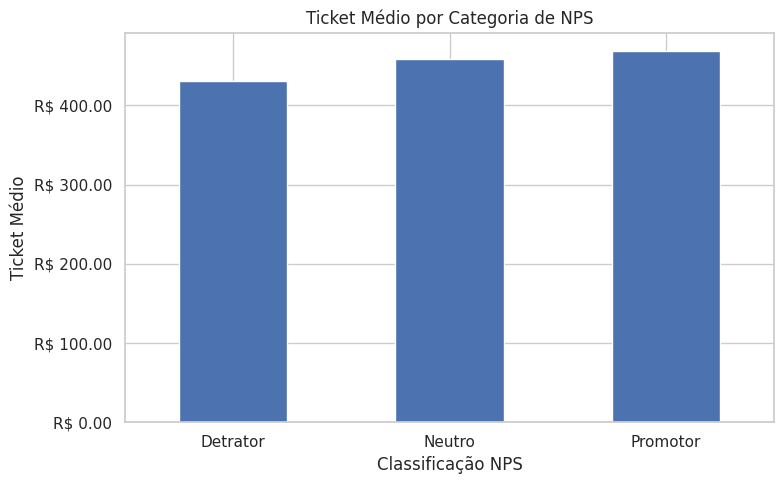

In [35]:
ticket_medio_nps = df.groupby("classificacao_nps")["order_value"].mean().reindex(["Detrator", "Neutro", "Promotor"])
ax = ticket_medio_nps.plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Médio por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Ticket Médio")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.2f}"))
plt.tight_layout()
plt.show()

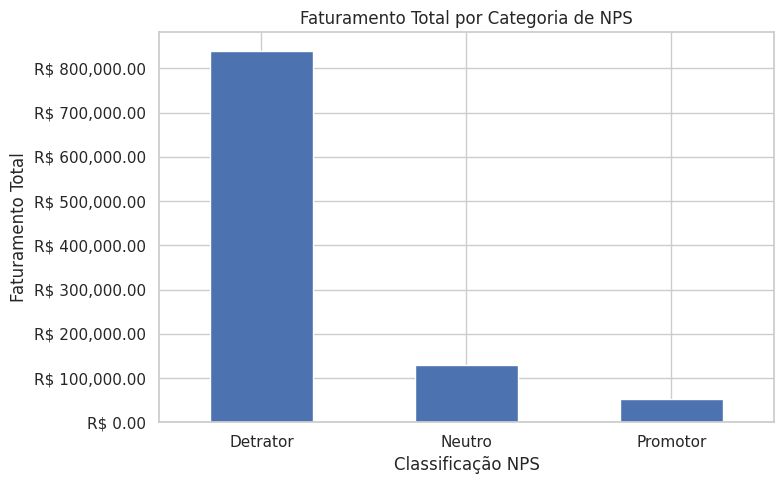

In [36]:
faturamento_total_nps = df.groupby("classificacao_nps")["order_value"].sum().reindex(["Detrator", "Neutro", "Promotor"])
ax = faturamento_total_nps.plot(kind="bar", figsize=(8, 5))
plt.title("Faturamento Total por Categoria de NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.2f}"))
plt.tight_layout()
plt.show()

A análise de faturamento por categoria de NPS permite observar como o valor financeiro dos pedidos está distribuído entre Detratores, Neutros e Promotores.

O faturamento total tende a ser influenciado pelo volume de clientes em cada categoria. Como a base possui maior concentração de Detratores, é esperado que esse grupo concentre parte relevante do faturamento total.

## 11. Faturamento associado ao atraso

Depois de analisar o faturamento por categoria de NPS, esta etapa avalia quanto do faturamento observado está associado a pedidos com e sem atraso.

O objetivo é conectar a dimensão logística com a dimensão financeira, observando se entregas atrasadas concentram volume relevante de pedidos, faturamento total ou ticket médio.

In [37]:
df["teve_atraso"] = (df["delivery_delay_days"] > 0).astype(int)

faturamento_atraso = df.groupby("teve_atraso").agg(
    total_pedidos=("order_value", "count"),
    faturamento_total=("order_value", "sum"),
    ticket_medio=("order_value", "mean"),
    mediana_pedido=("order_value", "median"),
    atraso_medio=("delivery_delay_days", "mean"),
    tentativas_medias=("delivery_attempts", "mean"),
    recompra_media_30d=("repeat_purchase_30d", "mean")
)

faturamento_atraso["percentual_pedidos_%"] = (faturamento_atraso["total_pedidos"] / faturamento_atraso["total_pedidos"].sum()) * 100
faturamento_atraso["participacao_faturamento_%"] = (faturamento_atraso["faturamento_total"] / faturamento_atraso["faturamento_total"].sum()) * 100

faturamento_atraso_plot = faturamento_atraso.copy()
faturamento_atraso_plot.index = faturamento_atraso_plot.index.map({0: "Sem atraso", 1: "Com atraso"})
faturamento_atraso_plot = faturamento_atraso_plot.reindex(["Sem atraso", "Com atraso"])

# Aplicar formatação de moeda para as colunas relevantes
for col in ["faturamento_total", "ticket_medio", "mediana_pedido"]:
    faturamento_atraso_plot[col] = faturamento_atraso_plot[col].apply(lambda x: f"R$ {x:,.2f}")

display(faturamento_atraso_plot)

,total_pedidos,faturamento_total,ticket_medio,mediana_pedido,atraso_medio,tentativas_medias,recompra_media_30d,percentual_pedidos_%,participacao_faturamento_%
teve_atraso,,,,,,,,,
Sem atraso,277,"R$ 116,492.02",R$ 420.55,R$ 342.72,0.00,2.01,0.34,11.83,11.42
Com atraso,2065,"R$ 903,237.96",R$ 437.40,R$ 380.12,2.33,2.01,0.06,88.17,88.58


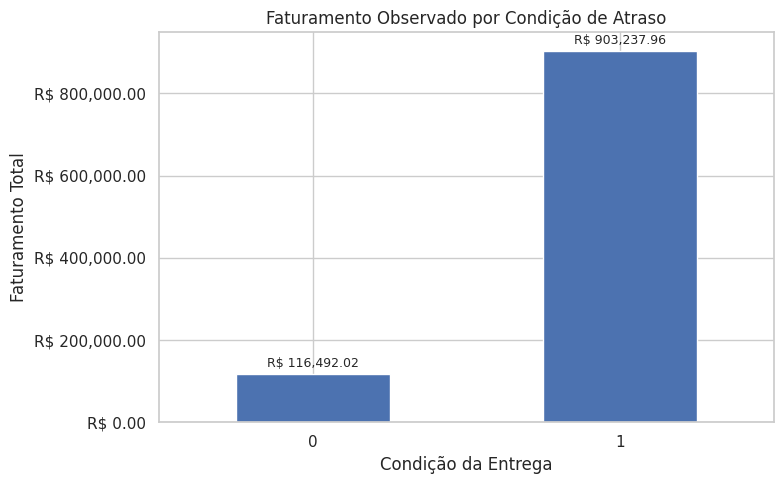

In [38]:
ax = faturamento_atraso["faturamento_total"].plot(kind="bar", figsize=(8, 5)) # Use o DataFrame original com dados numéricos
plt.title("Faturamento Observado por Condição de Atraso")
plt.xlabel("Condição da Entrega")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.2f}"))
for container in ax.containers:
    ax.bar_label(container, labels=[f"R$ {v:,.2f}" for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

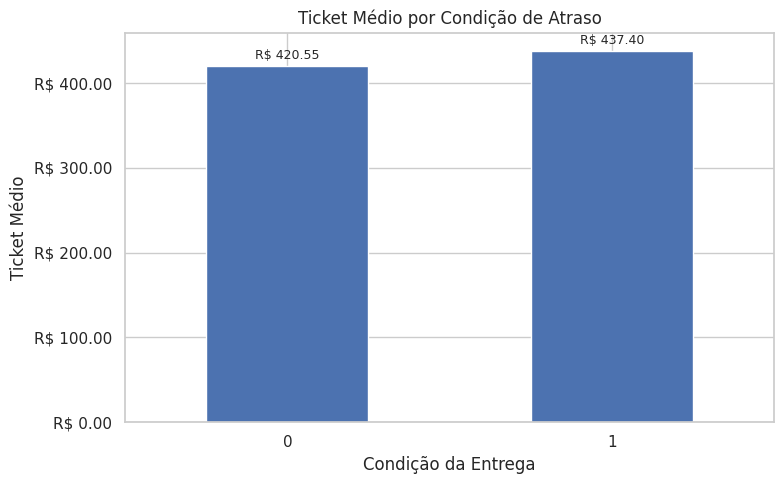

In [39]:
ax = faturamento_atraso["ticket_medio"].plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Médio por Condição de Atraso")
plt.xlabel("Condição da Entrega")
plt.ylabel("Ticket Médio")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.2f}"))
for container in ax.containers:
    ax.bar_label(container, labels=[f"R$ {v:,.2f}" for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [40]:
q75_order_value = df["order_value"].quantile(0.75)
high_value_delayed = df[(df["order_value"] >= q75_order_value) & (df["teve_atraso"] == 1)]
high_value_delayed_summary = high_value_delayed.agg({
    "order_value": ["count", "sum", "mean", "median"],
    "delivery_delay_days": ["mean", "median"],
    "delivery_attempts": ["mean", "median"],
    "repeat_purchase_30d": ["mean"]
})
high_value_delayed_summary

,order_value,delivery_delay_days,delivery_attempts,repeat_purchase_30d
count,522.00,NaN,NaN,NaN
sum,437774.77,NaN,NaN,NaN
mean,838.65,2.32,1.97,0.06
median,767.58,2.00,2.00,NaN


In [41]:
from IPython.display import display, Markdown

total_high_value = df[df["order_value"] >= q75_order_value].shape[0]
total_high_value_delayed = high_value_delayed.shape[0]
percentual_high_value_delayed = (total_high_value_delayed / total_high_value) * 100

markdown_output = f"""
### Análise de Pedidos de Alto Valor com Atraso

*   **Total de Pedidos de Alto Valor:** {total_high_value}
*   **Pedidos de Alto Valor com Atraso:** {total_high_value_delayed}
*   **Percentual de Pedidos de Alto Valor com Atraso:** **{percentual_high_value_delayed:.2f}%**
"""
display(Markdown(markdown_output))


### Análise de Pedidos de Alto Valor com Atraso

*   **Total de Pedidos de Alto Valor:** 586
*   **Pedidos de Alto Valor com Atraso:** 522
*   **Percentual de Pedidos de Alto Valor com Atraso:** **89.08%**


In [42]:
nps_high_value_delayed = (high_value_delayed["classificacao_nps"].value_counts(normalize=True) * 100)
nps_high_value_delayed = nps_high_value_delayed.reindex(["Detrator", "Neutro", "Promotor"])
nps_high_value_delayed

,proportion
classificacao_nps,
Detrator,85.82
Neutro,11.11
Promotor,3.07


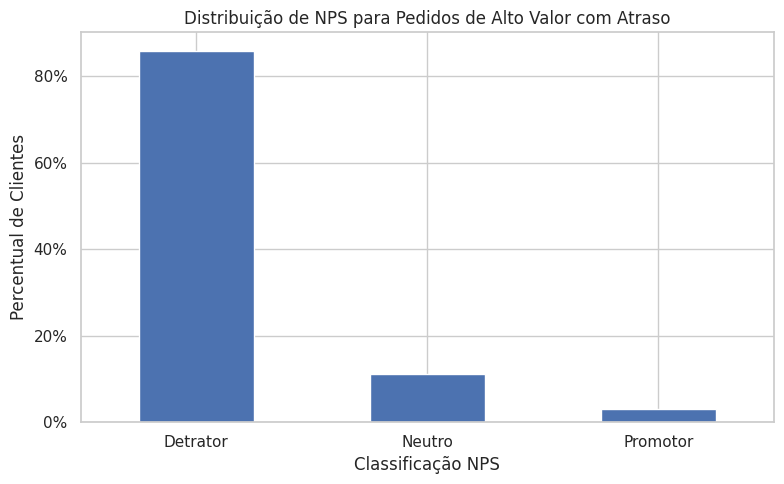

In [43]:
nps_high_value_delayed.plot(kind="bar", figsize=(8, 5))
plt.title("Distribuição de NPS para Pedidos de Alto Valor com Atraso")
plt.xlabel("Classificação NPS")
plt.ylabel("Percentual de Clientes")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

A análise mostra que os pedidos com atraso concentram maior faturamento observado em comparação aos pedidos sem atraso.

Esse resultado não deve ser interpretado como se o atraso gerasse faturamento. A leitura correta é que parte relevante da receita está associada a pedidos que tiveram uma experiência logística pior.

O ponto central é que o atraso aparece em pedidos financeiramente relevantes. Isso torna a melhoria logística uma pauta não apenas de satisfação, mas também de preservação de faturamento, retenção e recompra.

## 12. Análise regional

Depois de analisar atraso, frete, tentativas e faturamento, esta etapa avalia se existem diferenças relevantes por região.

O objetivo é verificar se o comportamento logístico é sistêmico ou se há regiões com maior concentração de atraso, frete, tentativas, Detratores ou faturamento observado.

In [44]:
regional_logistics = df.groupby("customer_region").agg(
    total_pedidos=("order_value", "count"),
    atraso_medio=("delivery_delay_days", "mean"),
    atraso_mediana=("delivery_delay_days", "median"),
    tempo_entrega_medio=("delivery_time_days", "mean"),
    frete_medio=("freight_value", "mean"),
    peso_medio_frete=("freight_ratio", "mean"),
    tentativas_medias=("delivery_attempts", "mean"),
    ticket_medio=("order_value", "mean"),
    mediana_pedido=("order_value", "median"),
    faturamento_total=("order_value", "sum"),
    recompra_media_30d=("repeat_purchase_30d", "mean")
).sort_values("atraso_medio", ascending=False)
display(regional_logistics.round(2))

,total_pedidos,atraso_medio,atraso_mediana,tempo_entrega_medio,frete_medio,peso_medio_frete,tentativas_medias,ticket_medio,mediana_pedido,faturamento_total,recompra_media_30d
customer_region,,,,,,,,,,,
Sudeste,493,2.11,2.00,8.16,38.50,0.15,2.04,416.53,359.35,205347.70,0.09
Centro-Oeste,434,2.08,2.00,7.96,37.96,0.15,2.00,444.75,383.66,193023.64,0.09
Nordeste,454,2.06,2.00,8.17,37.15,0.16,2.02,450.81,395.34,204666.64,0.08
Sul,489,2.03,2.00,8.01,38.21,0.16,2.02,436.47,374.21,213435.09,0.11
Norte,472,2.01,2.00,7.75,38.89,0.15,1.96,430.63,375.52,203256.91,0.08


In [45]:
regional_logistics["participacao_faturamento_%"] = (regional_logistics["faturamento_total"] / regional_logistics["faturamento_total"].sum()) * 100
regional_logistics["participacao_pedidos_%"] = (regional_logistics["total_pedidos"] / regional_logistics["total_pedidos"].sum()) * 100
display(regional_logistics.round(2))

,total_pedidos,atraso_medio,atraso_mediana,tempo_entrega_medio,frete_medio,peso_medio_frete,tentativas_medias,ticket_medio,mediana_pedido,faturamento_total,recompra_media_30d,participacao_faturamento_%,participacao_pedidos_%
customer_region,,,,,,,,,,,,,
Sudeste,493,2.11,2.00,8.16,38.50,0.15,2.04,416.53,359.35,205347.70,0.09,20.14,21.05
Centro-Oeste,434,2.08,2.00,7.96,37.96,0.15,2.00,444.75,383.66,193023.64,0.09,18.93,18.53
Nordeste,454,2.06,2.00,8.17,37.15,0.16,2.02,450.81,395.34,204666.64,0.08,20.07,19.39
Sul,489,2.03,2.00,8.01,38.21,0.16,2.02,436.47,374.21,213435.09,0.11,20.93,20.88
Norte,472,2.01,2.00,7.75,38.89,0.15,1.96,430.63,375.52,203256.91,0.08,19.93,20.15


In [46]:
regional_nps = pd.crosstab(df["customer_region"], df["classificacao_nps"], normalize="index") * 100
regional_nps = regional_nps.reindex(columns=["Detrator", "Neutro", "Promotor"])

regional_summary = regional_logistics.join(regional_nps[["Detrator", "Neutro", "Promotor"]])
regional_summary = regional_summary.sort_values("Detrator", ascending=False)

# Apply currency formatting to relevant columns
formatted_regional_summary = regional_summary.copy()
for col in ["faturamento_total", "ticket_medio", "mediana_pedido"]:
    formatted_regional_summary[col] = formatted_regional_summary[col].apply(lambda x: f"R$ {x:,.2f}")

display(formatted_regional_summary[["total_pedidos", "participacao_pedidos_%", "faturamento_total", "participacao_faturamento_%", "ticket_medio", "atraso_medio", "tempo_entrega_medio", "frete_medio", "peso_medio_frete", "tentativas_medias", "Detrator", "Neutro", "Promotor"]].round(2))

,total_pedidos,participacao_pedidos_%,faturamento_total,participacao_faturamento_%,ticket_medio,atraso_medio,tempo_entrega_medio,frete_medio,peso_medio_frete,tentativas_medias,Detrator,Neutro,Promotor
customer_region,,,,,,,,,,,,,
Nordeste,454,19.39,"R$ 204,666.64",20.07,R$ 450.81,2.06,8.17,37.15,0.16,2.02,84.58,10.79,4.63
Norte,472,20.15,"R$ 203,256.91",19.93,R$ 430.63,2.01,7.75,38.89,0.15,1.96,84.11,12.08,3.81
Centro-Oeste,434,18.53,"R$ 193,023.64",18.93,R$ 444.75,2.08,7.96,37.96,0.15,2.00,82.95,11.29,5.76
Sudeste,493,21.05,"R$ 205,347.70",20.14,R$ 416.53,2.11,8.16,38.50,0.15,2.04,82.76,12.58,4.67
Sul,489,20.88,"R$ 213,435.09",20.93,R$ 436.47,2.03,8.01,38.21,0.16,2.02,82.21,13.09,4.70


In [47]:
regional_nps = pd.crosstab(df["customer_region"], df["classificacao_nps"], normalize="index") * 100
regional_nps = regional_nps.reindex(columns=["Detrator", "Neutro", "Promotor"])
regional_nps

classificacao_nps,Detrator,Neutro,Promotor
customer_region,,,
Centro-Oeste,82.95,11.29,5.76
Nordeste,84.58,10.79,4.63
Norte,84.11,12.08,3.81
Sudeste,82.76,12.58,4.67
Sul,82.21,13.09,4.70


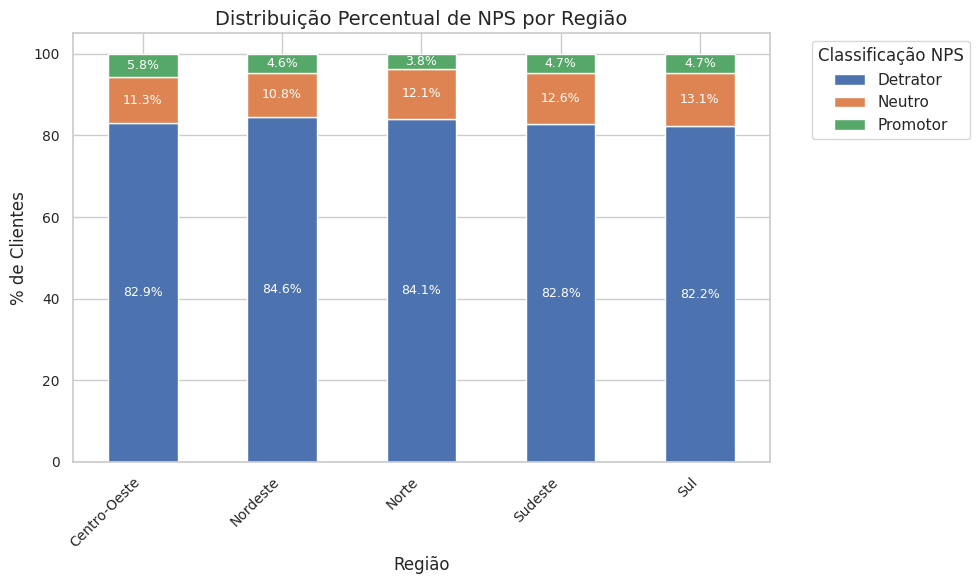

In [48]:
ax = regional_nps.plot(kind="bar", figsize=(10, 6), stacked=True) # Use stacked bar for clarity
plt.title("Distribuição Percentual de NPS por Região", fontsize=14) # Increase title font size
plt.xlabel("Região", fontsize=12) # Increase x-label font size
plt.ylabel("% de Clientes", fontsize=12) # Increase y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate and align x-axis labels
plt.yticks(fontsize=10)

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white') # Center labels, white color for contrast

plt.legend(title="Classificação NPS", bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

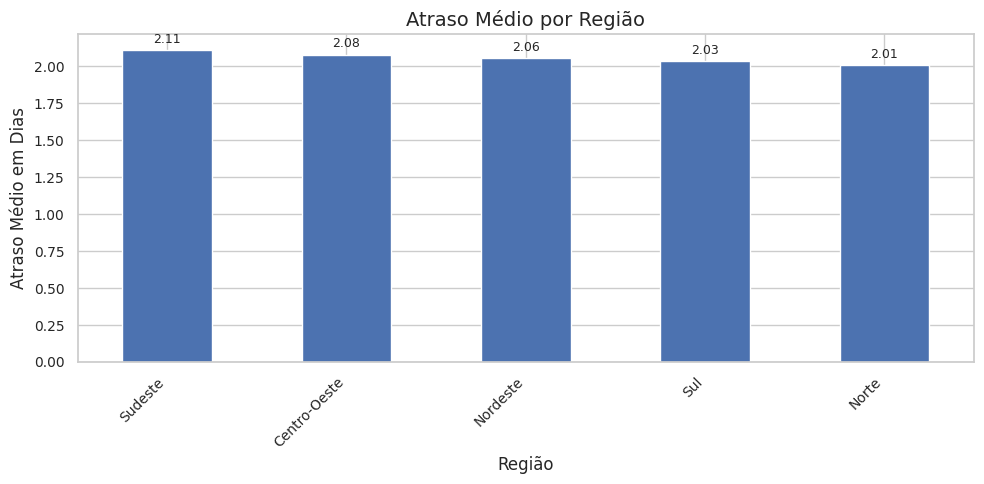

In [49]:
ax = regional_logistics["atraso_medio"].sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Atraso Médio por Região", fontsize=14) # Increase title font size
plt.xlabel("Região", fontsize=12) # Increase x-label font size
plt.ylabel("Atraso Médio em Dias", fontsize=12) # Increase y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate and align x-axis labels
plt.yticks(fontsize=10)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.2f}" for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

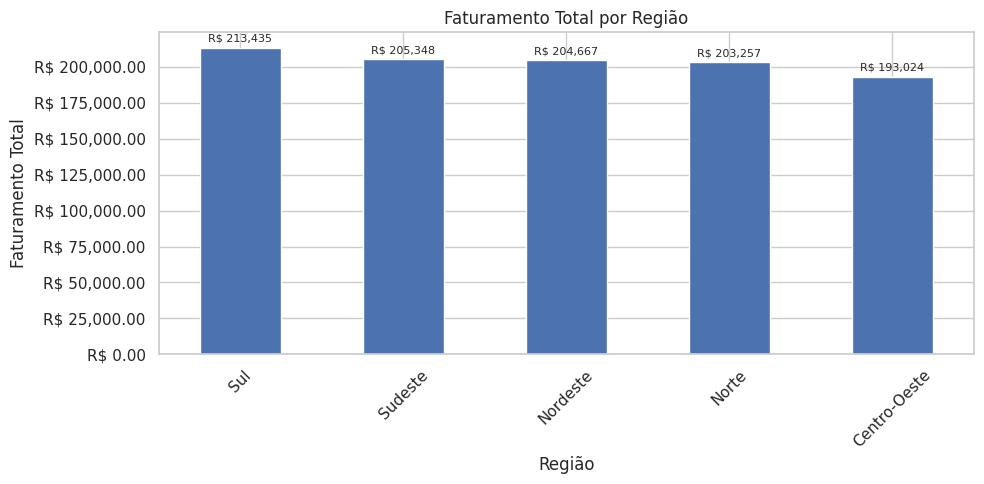

In [50]:
ax = regional_logistics["faturamento_total"].sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Faturamento Total por Região")
plt.xlabel("Região")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.2f}"))
for container in ax.containers:
    ax.bar_label(container, labels=[f"R$ {v:,.0f}" for v in container.datavalues], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [51]:
regional_nps = pd.crosstab(df["customer_region"], df["classificacao_nps"], normalize="index") * 100
regional_nps = regional_nps.reindex(columns=["Detrator", "Neutro", "Promotor"])

regional_summary = regional_logistics.join(regional_nps[["Detrator", "Neutro", "Promotor"]])
regional_summary = regional_summary.sort_values("Detrator", ascending=False)

# Apply currency formatting to relevant columns
formatted_regional_summary = regional_summary.copy()
for col in ["faturamento_total", "ticket_medio", "mediana_pedido"]:
    formatted_regional_summary[col] = formatted_regional_summary[col].apply(lambda x: f"R$ {x:,.2f}")

display(formatted_regional_summary[["total_pedidos", "participacao_pedidos_%", "faturamento_total", "participacao_faturamento_%", "ticket_medio", "atraso_medio", "tempo_entrega_medio", "frete_medio", "peso_medio_frete", "tentativas_medias", "Detrator", "Neutro", "Promotor"]])

,total_pedidos,participacao_pedidos_%,faturamento_total,participacao_faturamento_%,ticket_medio,atraso_medio,tempo_entrega_medio,frete_medio,peso_medio_frete,tentativas_medias,Detrator,Neutro,Promotor
customer_region,,,,,,,,,,,,,
Nordeste,454,19.39,"R$ 204,666.64",20.07,R$ 450.81,2.06,8.17,37.15,0.16,2.02,84.58,10.79,4.63
Norte,472,20.15,"R$ 203,256.91",19.93,R$ 430.63,2.01,7.75,38.89,0.15,1.96,84.11,12.08,3.81
Centro-Oeste,434,18.53,"R$ 193,023.64",18.93,R$ 444.75,2.08,7.96,37.96,0.15,2.00,82.95,11.29,5.76
Sudeste,493,21.05,"R$ 205,347.70",20.14,R$ 416.53,2.11,8.16,38.50,0.15,2.04,82.76,12.58,4.67
Sul,489,20.88,"R$ 213,435.09",20.93,R$ 436.47,2.03,8.01,38.21,0.16,2.02,82.21,13.09,4.70


A análise regional permite observar se o comportamento logístico e a satisfação variam de forma relevante entre as regiões.

Ao comparar atraso médio, tempo de entrega, frete, tentativas, ticket médio, faturamento total e distribuição de NPS, conseguimos avaliar se o problema está concentrado em regiões específicas ou se aparece de forma mais sistêmica na operação.

## 13. Correlação entre NPS, logística e pedido

Nesta etapa, analisamos a correlação entre o NPS e as principais variáveis numéricas relacionadas à logística, pedido e recompra.

A correlação ajuda a identificar associações lineares entre variáveis. Esta análise não deve ser interpretada como causalidade, mas como uma evidência estatística inicial para apoiar as hipóteses do EDA e a seleção de variáveis para etapas futuras de modelagem.

In [52]:
corr_cols = ["nps_score", "delivery_delay_days", "delivery_time_days", "freight_value", "freight_ratio", "order_value", "items_quantity", "delivery_attempts", "repeat_purchase_30d"]
corr_matrix = df[corr_cols].corr()
corr_matrix

,nps_score,delivery_delay_days,delivery_time_days,freight_value,freight_ratio,order_value,items_quantity,delivery_attempts,repeat_purchase_30d
nps_score,1.00,-0.55,0.01,-0.04,-0.07,0.03,0.00,0.02,0.60
delivery_delay_days,-0.55,1.00,-0.01,0.00,0.01,0.02,-0.01,0.01,-0.31
delivery_time_days,0.01,-0.01,1.00,-0.02,-0.01,-0.02,0.02,-0.01,0.01
freight_value,-0.04,0.00,-0.02,1.00,0.21,-0.02,-0.01,0.01,-0.02
freight_ratio,-0.07,0.01,-0.01,0.21,1.00,-0.54,-0.01,0.01,-0.02
order_value,0.03,0.02,-0.02,-0.02,-0.54,1.00,0.01,-0.01,0.02
items_quantity,0.00,-0.01,0.02,-0.01,-0.01,0.01,1.00,-0.01,0.01
delivery_attempts,0.02,0.01,-0.01,0.01,0.01,-0.01,-0.01,1.00,0.01
repeat_purchase_30d,0.60,-0.31,0.01,-0.02,-0.02,0.02,0.01,0.01,1.00


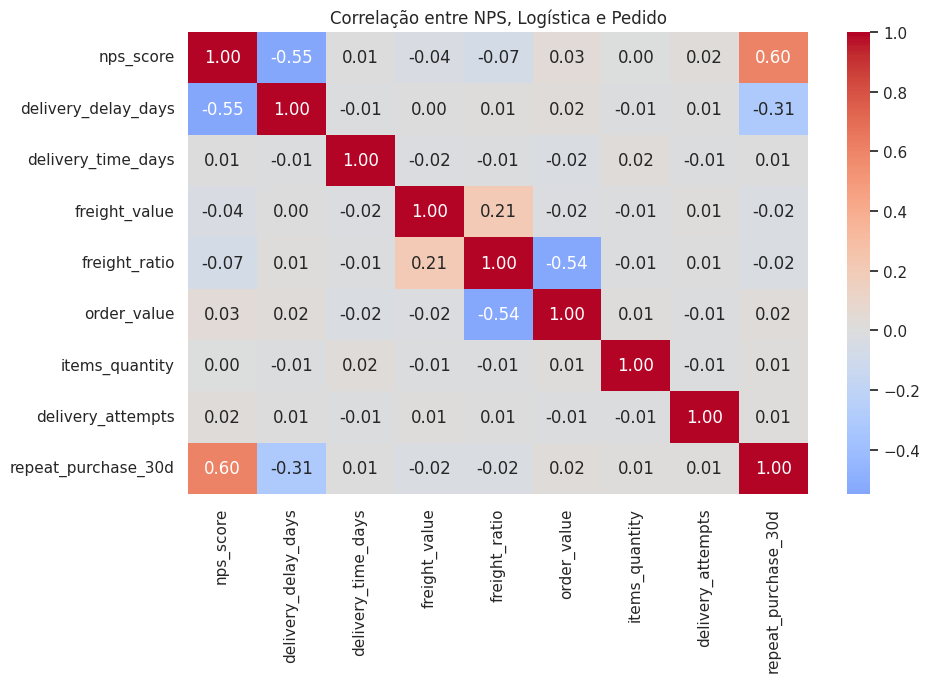

In [53]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre NPS, Logística e Pedido")
plt.show()

In [54]:
corr_nps = corr_matrix["nps_score"].drop("nps_score").sort_values()
corr_nps

,nps_score
delivery_delay_days,-0.55
freight_ratio,-0.07
freight_value,-0.04
items_quantity,0.00
delivery_time_days,0.01
delivery_attempts,0.02
order_value,0.03
repeat_purchase_30d,0.60


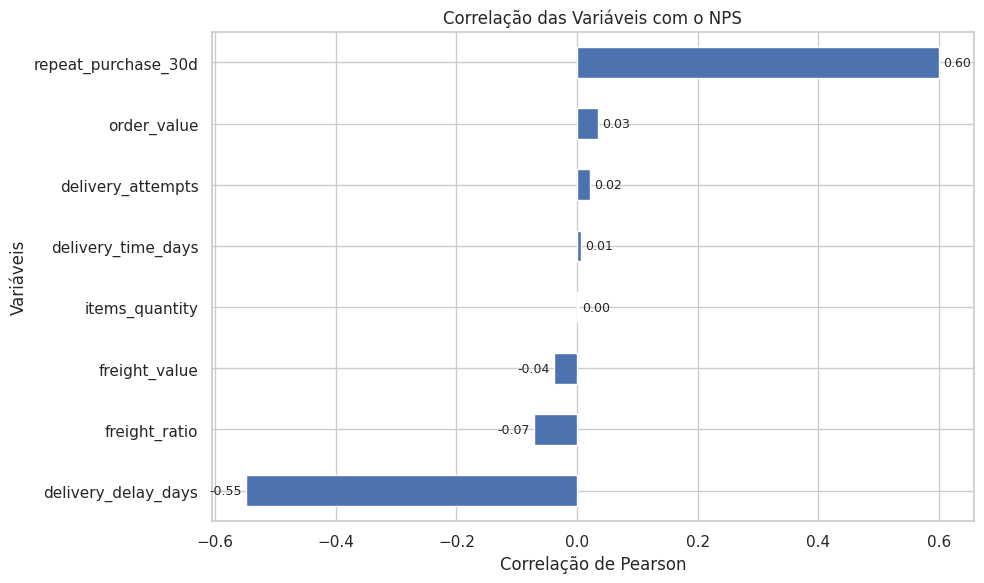

In [55]:
ax = corr_nps.plot(kind="barh", figsize=(10, 6))
plt.title("Correlação das Variáveis com o NPS")
plt.xlabel("Correlação de Pearson")
plt.ylabel("Variáveis")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.2f}" for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

A matriz de correlação permite observar quais variáveis apresentam maior associação linear com o NPS.

Se `delivery_delay_days` apresentar correlação negativa relevante, isso reforça o achado de que o atraso de entrega está associado à menor satisfação. Caso `repeat_purchase_30d` apresente correlação positiva, isso indica que clientes com recompra em 30 dias tendem a apresentar maior NPS.

O comparativo V1 vs V2 mostrou que a remoção dos registros com `nps_score = 0` não alterou a estrutura principal do problema.

## 14. Teste estatístico opcional: atraso entre categorias NPS

Como a distribuição de atraso pode não seguir normalidade, usamos o teste de Kruskal-Wallis para verificar se há diferença estatisticamente significativa no atraso entre Detratores, Neutros e Promotores.

In [69]:
from IPython.display import display, Markdown
from scipy.stats import kruskal

grupo_detrator = df[df["classificacao_nps"] == "Detrator"]["delivery_delay_days"]
grupo_neutro = df[df["classificacao_nps"] == "Neutro"]["delivery_delay_days"]
grupo_promotor = df[df["classificacao_nps"] == "Promotor"]["delivery_delay_days"]

stat, p_value = kruskal(grupo_detrator, grupo_neutro, grupo_promotor)

alpha = 0.05

conclusion = ""
interpretation = ""
if p_value < alpha:
    conclusion = "rejeitamos a hipótese nula"
    interpretation = "há uma **diferença estatisticamente significativa** na distribuição dos dias de atraso de entrega entre pelo menos dois dos grupos de NPS (Detratores, Neutros, Promotores)."
else:
    conclusion = "não rejeitamos a hipótese nula"
    interpretation = "não há diferença estatisticamente significativa na distribuição dos dias de atraso de entrega entre os grupos de NPS."

markdown_output = f"""
### Resultados do Teste de Kruskal-Wallis

**Variável Analisada:** Atraso de Entrega (`delivery_delay_days`)

**Grupos Comparados:** Detratores, Neutros e Promotores (`classificacao_nps`)

-   **Estatística H (Kruskal-Wallis):** `{stat:.4f}`
-   **Valor-p:** `{p_value:.4f}`
-   **Nível de Significância (alpha):** `{alpha}`

---

**Conclusão:**

Com base no valor-p (`{p_value:.4f}`) ser {'menor' if p_value < alpha else 'maior'} que alpha (`{alpha}`), **{conclusion}**.

Isso sugere que {interpretation}
"""

display(Markdown(markdown_output))


### Resultados do Teste de Kruskal-Wallis

**Variável Analisada:** Atraso de Entrega (`delivery_delay_days`)

**Grupos Comparados:** Detratores, Neutros e Promotores (`classificacao_nps`)

-   **Estatística H (Kruskal-Wallis):** `341.6352`
-   **Valor-p:** `0.0000`
-   **Nível de Significância (alpha):** `0.05`

---

**Conclusão:**

Com base no valor-p (`0.0000`) ser menor que alpha (`0.05`), **rejeitamos a hipótese nula**.

Isso sugere que há uma **diferença estatisticamente significativa** na distribuição dos dias de atraso de entrega entre pelo menos dois dos grupos de NPS (Detratores, Neutros, Promotores).


In [70]:
from scipy.stats import mannwhitneyu
from itertools import combinations
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

# Variável analisada
variavel = "delivery_delay_days"

# Grupos de NPS
grupos = {
    "Detrator": df[df["classificacao_nps"] == "Detrator"][variavel].dropna(),
    "Neutro": df[df["classificacao_nps"] == "Neutro"][variavel].dropna(),
    "Promotor": df[df["classificacao_nps"] == "Promotor"][variavel].dropna()
}

resultados = []

for grupo1, grupo2 in combinations(grupos.keys(), 2):
    dados_g1 = grupos[grupo1]
    dados_g2 = grupos[grupo2]

    stat, p_value = mannwhitneyu(
        dados_g1,
        dados_g2,
        alternative="two-sided"
    )

    media_g1 = dados_g1.mean()
    media_g2 = dados_g2.mean()
    mediana_g1 = dados_g1.median()
    mediana_g2 = dados_g2.median()

    resultados.append({
        "Comparação": f"{grupo1} vs {grupo2}",
        "N grupo 1": len(dados_g1),
        "N grupo 2": len(dados_g2),
        "Média grupo 1": media_g1,
        "Média grupo 2": media_g2,
        "Mediana grupo 1": mediana_g1,
        "Mediana grupo 2": mediana_g2,
        "Diferença mediana": mediana_g1 - mediana_g2,
        "Estatística U": stat,
        "p-valor": p_value
    })

resultado_posthoc = pd.DataFrame(resultados)

# Correção de Bonferroni para múltiplas comparações
n_comparacoes = len(resultado_posthoc)

resultado_posthoc["p-valor ajustado"] = (
    resultado_posthoc["p-valor"] * n_comparacoes
).clip(upper=1)

resultado_posthoc["Diferença significativa?"] = np.where(
    resultado_posthoc["p-valor ajustado"] < 0.05,
    "Sim",
    "Não"
)

# Interpretação automática simples
def interpretar_linha(row):
    if row["Diferença significativa?"] == "Não":
        return "Não há diferença estatisticamente significativa entre os grupos."

    grupo1, grupo2 = row["Comparação"].split(" vs ")

    if row["Diferença mediana"] > 0:
        return f"{grupo1} apresenta mediana de atraso maior que {grupo2}."
    elif row["Diferença mediana"] < 0:
        return f"{grupo2} apresenta mediana de atraso maior que {grupo1}."
    else:
        return "Há diferença estatística, mas as medianas são iguais; verificar distribuição e dispersão."

resultado_posthoc["Interpretação"] = resultado_posthoc.apply(interpretar_linha, axis=1)

display(Markdown("### Resultados dos Testes Post-Hoc de Mann-Whitney com Correção de Bonferroni"))

with pd.option_context("display.float_format", "{:.8f}".format):
    display(resultado_posthoc)

### Resultados dos Testes Post-Hoc de Mann-Whitney com Correção de Bonferroni

,Comparação,N grupo 1,N grupo 2,Média grupo 1,Média grupo 2,Mediana grupo 1,Mediana grupo 2,Diferença mediana,Estatística U,p-valor,p-valor ajustado,Diferença significativa?,Interpretação
0,Detrator vs Neutro,1951,281,2.27780625,1.05338078,2.00000000,1.00000000,1.00000000,420184.00000000,0.00000000,0.00000000,Sim,Detrator apresenta mediana de atraso maior que...
1,Detrator vs Promotor,1951,110,2.27780625,0.71818182,2.00000000,1.00000000,1.00000000,179388.50000000,0.00000000,0.00000000,Sim,Detrator apresenta mediana de atraso maior que...
2,Neutro vs Promotor,281,110,1.05338078,0.71818182,1.00000000,1.00000000,0.00000000,18723.50000000,0.00053903,0.00161709,Sim,"Há diferença estatística, mas as medianas são ..."


In [58]:
df.groupby("classificacao_nps")["delivery_delay_days"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).reindex(["Detrator", "Neutro", "Promotor"])

,count,mean,median,std,min,max
classificacao_nps,,,,,,
Detrator,1951,2.28,2.00,1.33,0,7
Neutro,281,1.05,1.00,0.89,0,4
Promotor,110,0.72,1.00,0.78,0,3


O teste de Kruskal-Wallis indicou que existe diferença estatisticamente significativa na distribuição dos dias de atraso entre as categorias de NPS.

Como o teste não informa entre quais grupos ocorre a diferença, foi realizado um teste par a par de Mann-Whitney com correção de Bonferroni.

A partir das comparações par a par e das medidas descritivas, é possível identificar quais grupos apresentam diferenças significativas e qual categoria concentra maior atraso médio ou mediano.

## 15. Relação do P3 com o modelo preditivo

As análises realizadas neste notebook não têm como objetivo treinar o modelo preditivo, mas preparar evidências e variáveis relevantes para a próxima etapa.

O P3 aprofunda a análise das variáveis de logística e pedido, identificando padrões entre atraso, frete, tentativas, valor do pedido, região e classificação NPS. Esses achados ajudam a selecionar e justificar variáveis que poderão ser usadas posteriormente em modelos de regressão ou classificação de NPS.

Dessa forma, o P3 contribui para a etapa preditiva ao indicar quais variáveis apresentam maior associação exploratória com a satisfação do cliente e quais dimensões operacionais podem apoiar recomendações acionáveis para logística e atendimento.

## 16. Resumo executivo dos achados do P3

### O que o P3 analisou

Este notebook aprofundou a análise exploratória das variáveis de logística e pedido a partir da base processada V2, na qual os registros com `nps_score = 0` foram removidos para análise de robustez.

O foco foi entender como atraso de entrega, faixas de atraso, ponto de ruptura, frete, peso proporcional do frete, tentativas de entrega, valor do pedido, região, recompra e faturamento observado se comportam entre Detratores, Neutros e Promotores.

### Principais achados

| Achado | Interpretação |
|---|---|
| A base V2 ainda apresenta forte concentração de Detratores | Mesmo após remover os registros com NPS igual a zero, a insatisfação continua elevada |
| O atraso permanece como variável central da análise | Atrasos maiores aparecem associados à menor satisfação |
| A análise por faixas permite observar o ponto de ruptura no atraso | O atraso deixa de ser analisado apenas pela média e passa a ser observado por intervalos operacionais |
| O peso proporcional do frete complementa a análise do frete absoluto | O impacto do frete deve ser analisado em relação ao valor total do pedido |
| Múltiplas tentativas de entrega indicam fricção logística | Pedidos com mais tentativas podem representar dificuldade operacional ou falha de comunicação |
| O faturamento com atraso merece atenção | Pedidos atrasados podem concentrar faturamento relevante, o que torna a melhoria logística importante para satisfação e preservação de receita |
| A análise regional ajuda a avaliar se o problema é sistêmico | Diferenças ou semelhanças entre regiões orientam ações gerais ou específicas |
| A correlação final reforça os achados exploratórios | Variáveis como atraso e recompra ajudam a indicar quais atributos podem ser usados na etapa futura de modelagem |

### Recomendações a partir do EDA

- Monitorar pedidos com atraso desde os primeiros dias.
- Usar faixas de atraso para identificar o ponto de ruptura da experiência.
- Avaliar pedidos com múltiplas tentativas como sinal de fricção logística.
- Analisar o peso proporcional do frete, e não apenas o valor absoluto do frete.
- Cruzar atraso com valor do pedido para priorizar melhorias em pedidos financeiramente relevantes.
- Avaliar diferenças regionais para entender se a atuação deve ser localizada ou sistêmica.
- Usar as variáveis analisadas no P3 como insumo para a etapa futura de modelagem preditiva de NPS.

### Conclusão

O P3 mostrou que a experiência logística deve ser analisada como uma dimensão relevante da satisfação do cliente. Atraso, tentativas de entrega, peso proporcional do frete e comportamento regional ajudam a explicar padrões observados entre Detratores, Neutros e Promotores.

A análise também conectou logística e faturamento observado ao mostrar que pedidos com atraso podem envolver valores financeiros relevantes. Portanto, a melhoria logística não deve ser vista apenas como uma ação operacional, mas também como uma oportunidade de melhorar satisfação, recompra e preservação do faturamento.

Embora este notebook utilize a base V2 para aprofundamento exploratório, o comparativo V1 vs V2 indica que a V1 deve permanecer como referência principal para produção, pois mantém os clientes com NPS igual a zero, considerados Detratores genuínos. A V2 funciona como validação de robustez, mostrando que os padrões principais permanecem mesmo após a remoção dos casos extremos.

> O EDA geral encontrou o problema. O P3 explicou a mecânica logística desse problema: atraso, tentativas, frete e valor do pedido ajudam a entender onde a experiência se deteriora e onde a operação pode atuar para melhorar satisfação e preservar faturamento.